## This notebook aims to answer:

### 1.Why does the model predict churn?
### 2.Which features contribute most to churn?
### 3.What business actions can reduce churn?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data/processed/selected_features.csv')
df.head()

,session_recency_min,purchase_number_stddev,customer_value_month_lag0,purchase_recency_min,purchase_count_month_ma3,customer_value_month_ma3,purchase_number_sum,haspurchase_sum,session_count_month_lag0,purchase_number_max,...,session_recency_cv,session_recency_mean,purchase_recency_mean,purchase_count_sum,purchase_recency_max,time_step,session_recency_sum,start_year_sum,purchase_count_month_lag1,target_event
0,3.296586,7.359801,30.501347,10.381447,0.666667,31.98359,325,25,1,25,...,0.400700,93.046776,86.240555,26,148.34409,0,3721.870961,80773,1,0
1,12.257524,5.916080,0.000000,12.257524,0.666667,142.62169,210,20,0,20,...,0.434636,99.118000,100.179020,30,178.00300,0,5748.843796,117123,1,1
2,144.209300,6.782330,0.000000,144.209300,0.000000,0.00000,276,23,0,23,...,0.035127,155.845550,154.942000,40,161.49910,0,5454.594444,70665,0,1
3,0.443171,7.071068,344.579960,0.443171,5.500000,227.48508,300,24,7,24,...,1.493412,20.168068,17.992144,32,107.57222,0,584.873970,58577,12,0
4,49.352894,17.752934,0.000000,49.352894,0.000000,0.00000,1891,61,0,61,...,0.366169,123.920490,128.477250,64,179.55130,0,12020.287141,195874,0,1


In [3]:
with open('models/xgboost_model.pkl','rb') as file:
    model=pickle.load(file)

In [4]:
X=df.drop('target_event',axis=1)
y=df['target_event']

---
### Feature Importance:

In [5]:
importance_df=pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    model.feature_importances_

})
importance_df=importance_df.sort_values(
    by='Importance',
    ascending=False
)
importance_df.head(10)

,Feature,Importance
0,session_recency_min,0.312040
1,purchase_number_stddev,0.252674
15,purchase_number_cv,0.094224
3,purchase_recency_min,0.048553
26,time_step,0.047889
17,purchase_count_month_lag0,0.019796
4,purchase_count_month_ma3,0.016974
29,purchase_count_month_lag1,0.015924
19,purchase_revenue_month_lag1,0.014421
12,purchase_revenue_month_lag0,0.014057


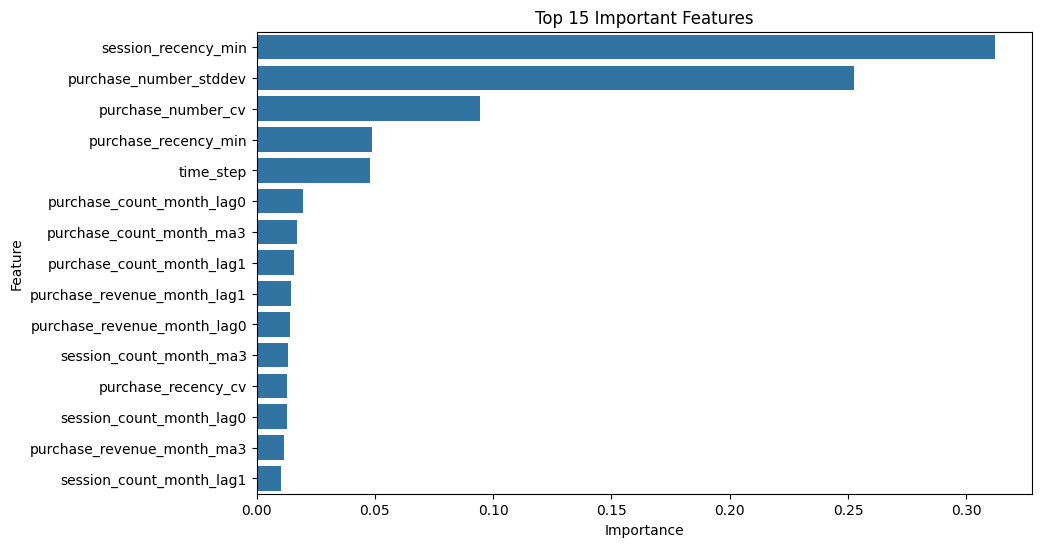

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Top 15 Important Features')
plt.show()

## Insights:
-The model relies heavily on customer recency,purchase activity, and customer value metrics.

-These features provide the strongest signal for identifying churn risk.

---
### SHAP Explainability:

In [7]:
explainer= shap.TreeExplainer(model)
shap_values= explainer.shap_values(X)

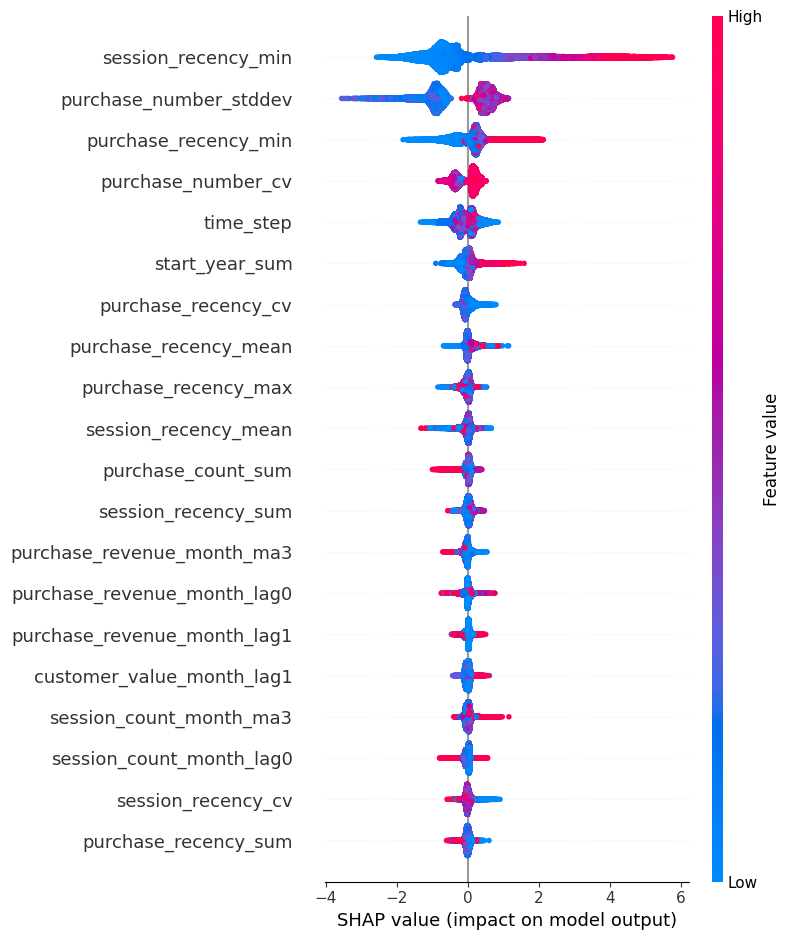

In [8]:
shap.summary_plot(
    shap_values,
    X,
    show=False
)
plt.show()

### SHAP identifies how each feature contributes
### toward increasing or decreasing churn probability.

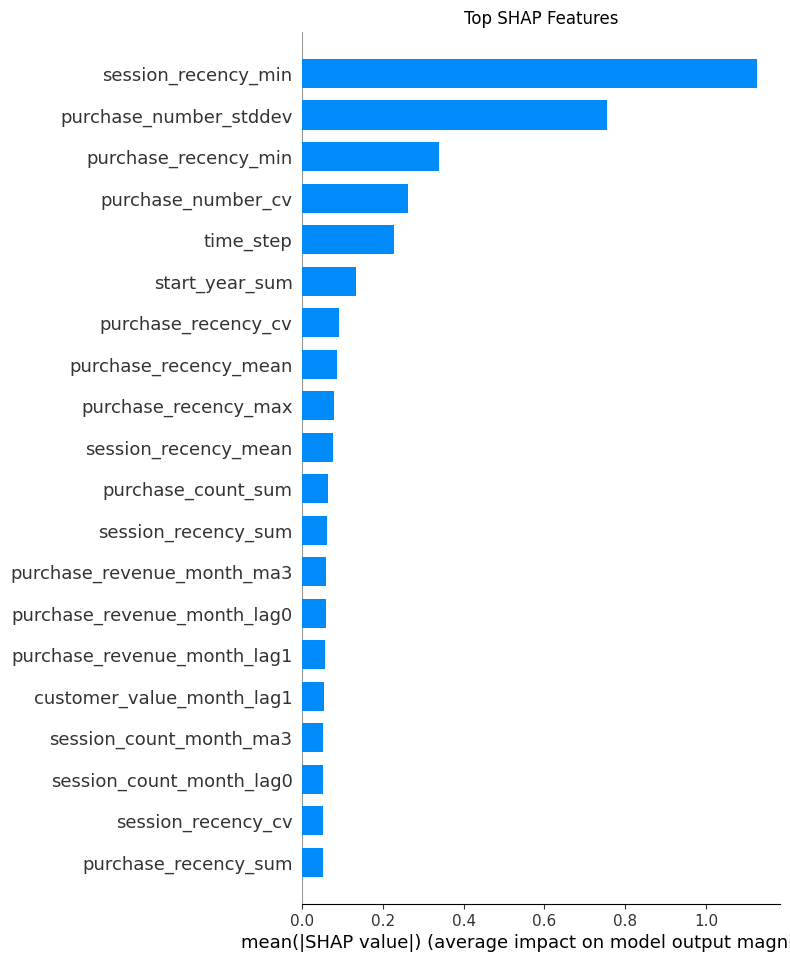

In [9]:
shap.summary_plot(
    shap_values,
    X,
    plot_type='bar',
    show=False
)
plt.title('Top SHAP Features')
plt.show()

### session_recency_mean

### High value
### → increases churn risk

### Low value
### → decreases churn risk

---
### Individual Customer Explaination:

In [10]:
customer_index=544
X.iloc[[customer_index]]

,session_recency_min,purchase_number_stddev,customer_value_month_lag0,purchase_recency_min,purchase_count_month_ma3,customer_value_month_ma3,purchase_number_sum,haspurchase_sum,session_count_month_lag0,purchase_number_max,...,customer_value_month_lag1,session_recency_cv,session_recency_mean,purchase_recency_mean,purchase_count_sum,purchase_recency_max,time_step,session_recency_sum,start_year_sum,purchase_count_month_lag1
544,115.19916,9.092121,0.0,115.19916,0.0,0.0,496,31,0,31,...,0.0,0.128541,135.29347,136.92445,97,177.28621,0,6088.205995,90855,0


In [11]:
prediction = model.predict(
    X.iloc[[customer_index]]
)
prediction

array([1])

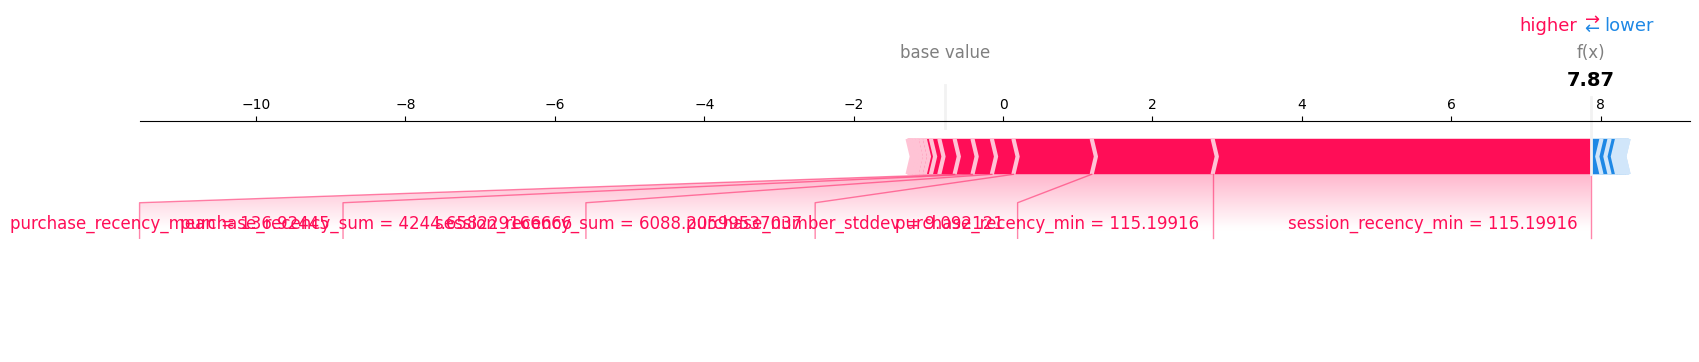

In [12]:
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X.iloc[customer_index],
    matplotlib=True
)

## Insight:
### This visualization explains why a specific
### customer was predicted as churned or retained.

---
### Business Insights:

In [13]:
importance_df.head(10)

,Feature,Importance
0,session_recency_min,0.312040
1,purchase_number_stddev,0.252674
15,purchase_number_cv,0.094224
3,purchase_recency_min,0.048553
26,time_step,0.047889
17,purchase_count_month_lag0,0.019796
4,purchase_count_month_ma3,0.016974
29,purchase_count_month_lag1,0.015924
19,purchase_revenue_month_lag1,0.014421
12,purchase_revenue_month_lag0,0.014057


### Business Insights:

1. Session recency is the strongest driver of customer churn.

2. Customers who stop visiting the platform for extended periods are significantly more likely to churn.

3. Purchase consistency plays a major role in retention. Customers with highly irregular purchasing behavior show increased churn risk.

4. Customers who have not made recent purchases are more likely to leave.

5. Higher purchase frequency reduces churn probability.

6. Customers generating consistent revenue are more likely to remain active.

7. Increased platform engagement, measured through session activity, contributes positively to customer retention.

8. Customer inactivity is the primary early warning signal for churn.

---
### Recommended Retention Strategies (Churn Prevention)

1. Identify customers with increasing session recency and target them with re-engagement campaigns.

2. Send personalized offers to customers who have not purchased recently.

3. Reward customers demonstrating consistent purchasing behavior through loyalty programs.

4. Monitor sudden drops in session activity as an early churn signal.

5. Create retention campaigns for customers whose purchase frequency is declining.

6. Provide exclusive incentives to high-value customers to encourage continued engagement.

7. Use churn prediction scores to proactively contact at-risk customers before they become inactive.